In [2]:
import numpy as np
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import matplotlib.image as mpimg
import seaborn as sns

import sklearn


In [ ]:

# Read the CSV file into a pandas DataFrame
file_path = 'data/Excel/third_round/merged_enrichment_scores_with_aa_column_third_threshold.xlsx'
df = pd.read_excel(file_path)

# Show the first couple of rows of the relevant columns
display(df)

,amino_acid_sequence,enrichment_score,num_replicates,averaged_enrichment_score
0,LNHHFYYV,[0.1494201476168534],1,0.149420
1,FTHHSYAG,[0.2124630124952891],1,0.212463
2,AWHHYYYI,[0.2232907823937248],1,0.223291
3,LGLFSFIP,[0.2278196077861901],1,0.227820
4,WVHHSYAN,[0.2278196077861901],1,0.227820
...,...,...,...,...
2019,GHPTNCND,[6.279767322970565],1,6.279767
2020,ACNNSSSS,[7.666316862184551],1,7.666317
2021,SCATKSTA,[7.910662076149551],1,7.910662
2022,SCTKNTSP,[8.80318330599458],1,8.803183


In [4]:
# Create a new column with the log2 of the averaged_enrichment_score
df['log2_averaged_enrichment_score'] = np.log2(df['averaged_enrichment_score'])

display(df)

,amino_acid_sequence,enrichment_score,num_replicates,averaged_enrichment_score,log2_averaged_enrichment_score
0,LNHHFYYV,[0.1494201476168534],1,0.149420,-2.742553
1,FTHHSYAG,[0.2124630124952891],1,0.212463,-2.234716
2,AWHHYYYI,[0.2232907823937248],1,0.223291,-2.163004
3,LGLFSFIP,[0.2278196077861901],1,0.227820,-2.134036
4,WVHHSYAN,[0.2278196077861901],1,0.227820,-2.134036
...,...,...,...,...,...
2019,GHPTNCND,[6.279767322970565],1,6.279767,2.650711
2020,ACNNSSSS,[7.666316862184551],1,7.666317,2.938534
2021,SCATKSTA,[7.910662076149551],1,7.910662,2.983798
2022,SCTKNTSP,[8.80318330599458],1,8.803183,3.138025


OneHot Encoding

In [5]:

def AA_hotencoding(variant):
    
    """  
    AA_hotencoding takes an amino acid sequence 'variant' of an arbitrary length,

    and returns a 20xlength one-hot encoding matrix 'onehot_encoded'.       

    """

    AAs = 'ARNDCQEGHILKMFPSTWYV'
    encoding_length = len(AAs)
    variant_length = len(variant)


    # Define a mapping of chars to integers
    char_to_int = dict((c, i) for i, c in enumerate(AAs))
    int_to_char = dict((i, c) for i, c in enumerate(AAs))


    # Encode input data 
    integer_encoded = [char_to_int[char] for i, char in enumerate(variant) if i <variant_length]
    
    # Start one-hot-encoding
    onehot_encoded = list()  

    for value in integer_encoded:
        letter = [0 for _ in range(encoding_length)]
        letter[value] = 1
        onehot_encoded.append(letter)              

    return onehot_encoded

In [6]:
# Example usage
example_sequence = "SIHHKYSS"
encoded_sequence = AA_hotencoding(example_sequence)

print("Example Sequence:", example_sequence)
print("One-Hot Encoded Sequence:")
for row in encoded_sequence:
    print(row)

Example Sequence: SIHHKYSS
One-Hot Encoded Sequence:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


In [7]:

# apply one-hot encoding to the 'amino_acid_sequence' column

# Step 1: Apply the AA_hotencoding function to the 'amino_acid_sequence' column
df['AA_hotencoding'] = df['amino_acid_sequence'].apply(AA_hotencoding)
display(df)

print(df.shape)

,amino_acid_sequence,enrichment_score,num_replicates,averaged_enrichment_score,log2_averaged_enrichment_score,AA_hotencoding
0,LNHHFYYV,[0.1494201476168534],1,0.149420,-2.742553,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,..."
1,FTHHSYAG,[0.2124630124952891],1,0.212463,-2.234716,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,..."
2,AWHHYYYI,[0.2232907823937248],1,0.223291,-2.163004,"[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,LGLFSFIP,[0.2278196077861901],1,0.227820,-2.134036,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,..."
4,WVHHSYAN,[0.2278196077861901],1,0.227820,-2.134036,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
...,...,...,...,...,...,...
2019,GHPTNCND,[6.279767322970565],1,6.279767,2.650711,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,..."
2020,ACNNSSSS,[7.666316862184551],1,7.666317,2.938534,"[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2021,SCATKSTA,[7.910662076149551],1,7.910662,2.983798,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2022,SCTKNTSP,[8.80318330599458],1,8.803183,3.138025,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


(2024, 6)


Create a Testset

In [8]:
# Train-Test split without Validation set, we don't need it for now
# Dataset size = 2024
# approximately 80% of the data will be used for training and 20% for testing
# 80% of 2024 = 1619.2

train_size = 1620

# Split into train and test set
train_set, test_set = np.split(df.sample(frac=1), [train_size])
print(test_set)


     amino_acid_sequence      enrichment_score  num_replicates  \
1053            SSFLEVPI  [0.6821765366355712]               1   
168             SVHHIYLA  [0.3936918445822177]               1   
1039            SIHHGYER  [0.6771499726814144]               1   
1987            RNQSKECS   [3.940154502515693]               1   
1445            DIHHSYIS  [0.8640382449148483]               1   
...                  ...                   ...             ...   
1751            AAHHDYCM   [1.153780799515923]               1   
2015            RSVPNACA   [5.994111471132922]               1   
808             NVKGWTDL   [0.603924167385877]               1   
1368            LDVAKFNG  [0.8152976259709338]               1   
65              VEHHYYMY   [0.334560263182517]               1   

      averaged_enrichment_score  log2_averaged_enrichment_score  \
1053                   0.682177                       -0.551783   
168                    0.393692                       -1.344861   
1039  

/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [9]:

# Convert the one-hot encoded lists to numpy arrays and stack them into feature matrices
# this is necessary for the sckit-learn library to work with the data

# TODO: best practise to make 20x8 matrix to 160x1 matrix?- it does not make a difference, 
# because the linear regression just adds and multiplies the values

x_train = np.asarray([np.asarray(value).flatten() for value in train_set["AA_hotencoding"].values])
y_train = train_set['log2_averaged_enrichment_score'].values


x_test = np.asarray([np.asarray(value).flatten() for value in test_set["AA_hotencoding"].values])
y_test = test_set['log2_averaged_enrichment_score'].values

Train a Linear Regression Model

In [10]:
# GOAL: Train a Linear Regression model to predict the log2_averaged_enrichment_score from the one-hot encoded amino acid sequences

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import pearsonr


# Initialize the Linear Regression model
lin_reg = LinearRegression()

# 5-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

pearsons = []

for train_idx, _ in kf.split(x_train):

    x_train_fold, y_train_fold = x_train[train_idx], y_train[train_idx]

    # Fit the model on the training data
    lin_reg.fit(x_train_fold, y_train_fold)

    # Apply the model to the one-hot encoded test set
    y_pred = lin_reg.predict(x_test)

    # Calculate Pearson Correlation Coefficient
    pearson_corr, _ = pearsonr(y_test, y_pred)
    pearsons.append(pearson_corr)

print(pearsons)
    



[0.6089646613391972, 0.6245050419218543, 0.5985067568122837, 0.6312966546549561, 0.6107617637588256, 0.6099514375164425, 0.6236033396028707, 0.6237604387664153, 0.6188960648648131, 0.6327273206927474]


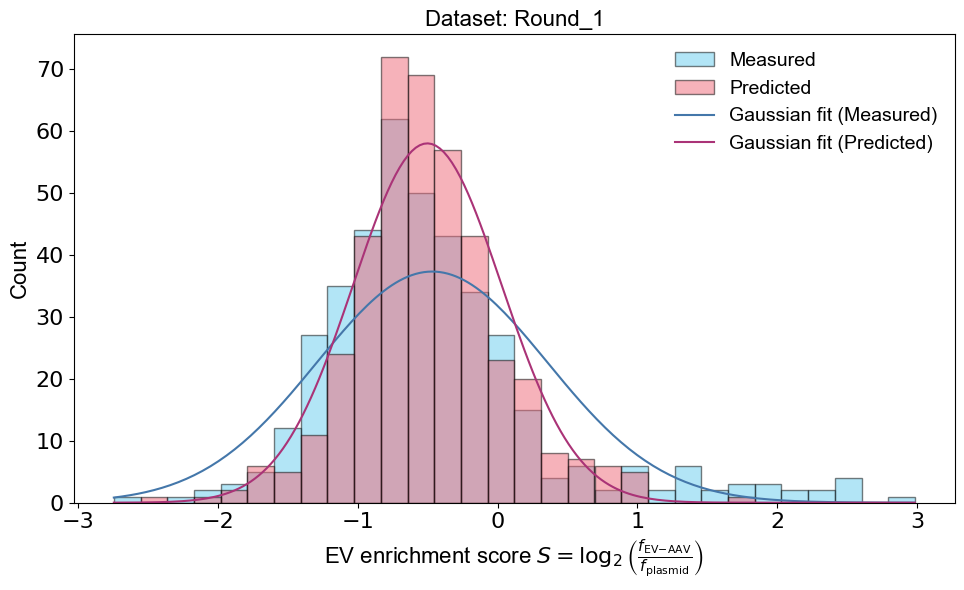

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- your y_test, y_pred should already be defined ---
# y_test = ...
# y_pred = ...

fig, ax = plt.subplots(figsize=(9.75, 6))

# Combine both datasets to define common bins
combined = np.concatenate([y_test, y_pred])

# Define bins from global min to max
bins = np.linspace(combined.min(), combined.max(), 31)  # 30 bins

counts_test, bins_test, _ = ax.hist(
    y_test,
    bins=bins,
    alpha=0.5,
    label='Measured',
    color='#66CCEE',
    edgecolor='black'
)

counts_pred, bins_pred, _ = ax.hist(
    y_pred,
    bins=bins,
    alpha=0.5,
    label='Predicted',
    color='#EE6677',
    edgecolor='black'
)

# x values for the fitted Gaussians
x_range = np.linspace(min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max()), 200)

# Compute mean and std (guard against zero std)
eps = 1e-8
mu_test, sigma_test = np.mean(y_test), np.std(y_test, ddof=0)
sigma_test = max(sigma_test, eps)

mu_pred, sigma_pred = np.mean(y_pred), np.std(y_pred, ddof=0)
sigma_pred = max(sigma_pred, eps)

# Evaluate normal pdfs
pdf_test = norm.pdf(x_range, loc=mu_test, scale=sigma_test)
pdf_pred = norm.pdf(x_range, loc=mu_pred, scale=sigma_pred)

# Scale pdfs to histogram counts:
# pdf * N * bin_width -> expected counts per bin
bin_width_test = bins_test[1] - bins_test[0]
bin_width_pred = bins_pred[1] - bins_pred[0]

density_test = pdf_test * len(y_test) * bin_width_test
density_pred = pdf_pred * len(y_pred) * bin_width_pred

# Plot fitted Gaussian curves on top of histograms
ax.plot(x_range, density_test, color='#4477AA', linewidth=1.5, label='Gaussian fit (Measured)')
ax.plot(x_range, density_pred, color='#AA3377', linewidth=1.5, label='Gaussian fit (Predicted)')

# Labels, title, legend and font settings (Arial)
ax.set_xlabel(r"EV enrichment score $S = \log_2\left(\frac{f_{\mathrm{EV\!-\!AAV}}}{f_{\mathrm{plasmid}}}\right)$",
              fontsize=16, fontname='Arial')
ax.set_ylabel('Count', fontsize=16, fontname='Arial')
ax.set_title('Dataset: Round_1', fontsize=16, fontname='Arial')

ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=14, prop={'family': 'Arial', 'size': 14}, frameon=False)

plt.tight_layout()
plt.show()

Validate The Model 

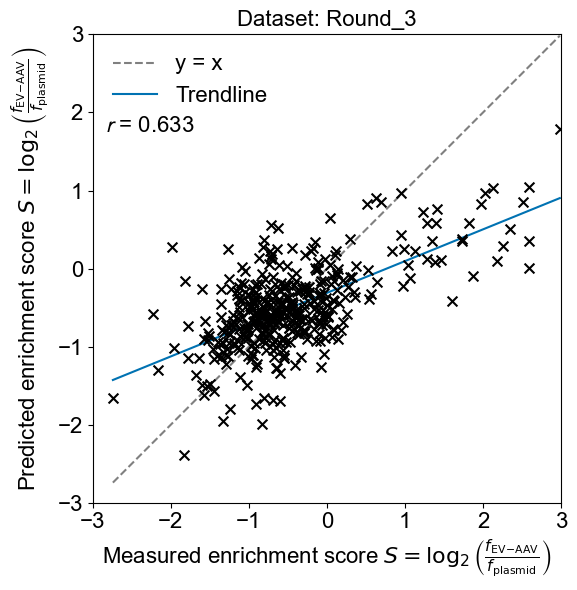

In [12]:
# Scatter plot: Predicted vs Measured with identity line, trendline, and Pearson r
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

# Measured (x) and Predicted (y)
x = np.array(y_test)
y = np.reshape(y_pred, (1,y_pred.shape[0]))[0]

# Pearson correlation
r_value, p_value = pearsonr(x, y)

# Fit linear regression trendline
slope, intercept = np.polyfit(x, y, 1)

# Range for plotting lines
line_x = np.linspace(min(x.min(), y.min()), max(x.max(), y.max()), 200)
trendline = slope * line_x + intercept

# Create figure and plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot data points with cross markers
ax.scatter(x, y, marker='x', s=50, linewidths=1.5, c='black', zorder=3)

# Identity line (y = x)
ax.plot(line_x, line_x, linestyle='--', color='gray', linewidth=1.5, label='y = x')

# Trendline
ax.plot(line_x, trendline, color='#0072B2', linewidth=1.5, label='Trendline')

# Set labels with fontsize and Arial font
ax.set_xlabel(r"Measured enrichment score $S = \log_2\left(\frac{f_{\mathrm{EV\!-\!AAV}}}{f_{\mathrm{plasmid}}}\right)$", fontsize=16, fontname='Arial')
ax.set_ylabel(r"Predicted enrichment score $S = \log_2\left(\frac{f_{\mathrm{EV\!-\!AAV}}}{f_{\mathrm{plasmid}}}\right)$", fontsize=16, fontname='Arial')
ax.set_title('Dataset: Round_3', fontsize=16, fontname='Arial')

# Set tick label fontsize
ax.tick_params(axis='both', which='major', labelsize=16, labelfontfamily='Arial')

# Set equal aspect ratio
ax.set_aspect('equal', adjustable='box')

# Annotate Pearson correlation coefficient
ax.text(0.025, 0.825, f'$\\mathcal{{r}}$ = {r_value:.3f}', transform=ax.transAxes, ha='left', va='top', 
        fontsize=16, fontname='Arial')

# Set legend
ax.legend(fontsize=16, loc='upper left', frameon=False, prop={'family': 'Arial', 'size': 16})

ax.set_ylim(-3, 3)
ax.set_xlim(-3, 3)
plt.tight_layout()

plt.show()